# Phase 7 -- Barren-plateau check: direct gradient-variance measurement

Experiments 1-3 established that hybrid-model accuracy does **not** rise monotonically with either
`n_qubits` or `n_qlayers` on this 3-class MNIST subset, and Experiment 4 found that the *shallow*
configuration (`depth_1`) was the unstable one across seeds -- class-collapse in 2/5 seeds -- which is
the opposite of what a vanishing-gradient barren plateau would predict.

The problem with stopping there is that **accuracy cannot distinguish two very different causes** of a
flat sweep:

1. **Ceiling effect** -- the task is easy enough that every configuration already saturates, so there is
   no headroom for extra qubits or layers to show up in.
2. **Barren plateau** -- gradients have decayed to the point that the optimiser cannot make progress,
   so extra capacity is unusable.

Both produce a flat accuracy curve. This notebook stops inferring and measures the gradient landscape
directly, using the standard diagnostic from **McClean et al. (2018), "Barren plateaus in quantum neural
network training landscapes"**: fix a target parameter $\theta$, draw all other circuit weights uniformly
from $[0, 2\pi)$, and estimate $\mathrm{Var}(\partial C / \partial \theta)$ over $N$ random circuits.

Under a barren plateau this variance decays **exponentially** in the number of qubits, which appears as a
**straight-line decline on a log-scale plot**. A flat line rules the effect out over the range measured.

## What is measured

| | |
|---|---|
| Circuit | Imported from `src/models/quantum_layer.py` -- `qml.AngleEmbedding` + `qml.BasicEntanglerLayers`, the exact circuit `HybridCNN` trains |
| Target parameter | `weights[0][0]`, the first rotation weight (`param_index = 0`) |
| Reference input | All-zero embedding angles, leaving the register in $|0\ldots0\rangle$ (McClean's convention). A non-zero robustness check is run in section 6 |
| Samples | $N = 200$ random weight draws per configuration |
| Global cost | $C = \sum_i \langle Z_i \rangle$ over all measured wires -- what `HybridCNN`'s `output_head` actually reads |
| Local cost | $C = \langle Z_0 \rangle$, a single wire -- the standard barren-plateau mitigation |
| Gradients | Backpropagation through the simulator; `tests/test_barren_plateau.py` asserts this matches parameter-shift to `atol=1e-8` |

Both cost functions are differentiated **from the same forward pass at the same weights**, so the
global/local comparison is *paired* -- any difference between them is real, not sampling noise.

## Sweeps

- **Sweep A (qubit count)**: `n_qubits` in {2, 4, 6, 8}, `n_qlayers` fixed at 2 -- mirrors Experiment 3's Sweep A.
  Optionally extended to {10, 12, 14} as a diagnostic-only range (see below).
- **Sweep B (circuit depth)**: `n_qlayers` in {1, 2, 3, 4}, `n_qubits` fixed at 4 -- mirrors Experiment 3's Sweep B.

**On the extended range:** no training happens here -- only gradient sampling at random weights -- so each
extra qubit costs seconds rather than a 15-epoch run. The trainable-model range (2-8 qubits) was chosen for
training convenience; the barren-plateau question is about the *ansatz*, so the diagnostic deliberately looks
past that window. Points beyond 8 qubits describe the circuit family, not any model trained in this dissertation,
and the plots shade the two regions differently.

## Reproducibility

Weight draws are seeded via `sampling_seed` (=42) through `src/utils/seed.py`. It is named separately from the
`data_seed`/`training_seed` pair used elsewhere because neither applies: no data is loaded and no model is trained.
Every grid point re-seeds from the same value, so configurations share a common random-number stream and
differences between them come from the circuit, not the draw.

**Reproduce with:**
```bash
python -m src.experiments.run_barren_plateau_check --sweep qubits --extended
python -m src.experiments.run_barren_plateau_check --sweep depth
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import Image, display

project_root = Path.cwd().resolve()
if not (project_root / 'results').exists():
    project_root = Path('d:/Dissertation/qcnn-dissertation').resolve()

sys.path.insert(0, str(project_root))

from src.experiments.run_barren_plateau_check import (
    COST_TYPES, build_reference_input, sample_gradients,
)
from src.models.quantum_layer import make_quantum_layer
from src.utils.plotting import GRADIENT_ZERO_TOL

pd.set_option('display.float_format', lambda v: f'{v:.6e}' if abs(v) < 1e-3 and v != 0 else f'{v:.6f}')

print('Imports OK')
print(f'Project root: {project_root}')
print(f'Cost types measured: {COST_TYPES}')

Imports OK
Project root: D:\Dissertation\qcnn-dissertation
Cost types measured: ('global', 'local')


## Configuration

Points at `configs/barren_plateau/*.yaml` and the sweep outputs written by
`run_barren_plateau_check.py` under `results/barren_plateau/`.

In [2]:
def load_config(config_path):
    with open(config_path, 'r', encoding='utf-8') as f:
        return yaml.safe_load(f)

QUBIT_POINTS = [2, 4, 6, 8]
EXTENDED_QUBIT_POINTS = [10, 12, 14]
DEPTH_POINTS = [1, 2, 3, 4]

CONFIG_DIR = project_root / 'configs' / 'barren_plateau'
RESULTS_DIR = project_root / 'results' / 'barren_plateau'
SUMMARY_CSV = RESULTS_DIR / 'summary.csv'

SWEEP_A_CONFIGS = [CONFIG_DIR / f'qubits_{n}.yaml' for n in QUBIT_POINTS + EXTENDED_QUBIT_POINTS]
SWEEP_B_CONFIGS = [CONFIG_DIR / f'depth_{n}.yaml' for n in DEPTH_POINTS]

rows = []
for path in SWEEP_A_CONFIGS + SWEEP_B_CONFIGS:
    if not path.exists():
        continue
    cfg = load_config(path)
    rows.append({
        'config': path.name,
        'n_qubits': cfg['model']['n_qubits'],
        'n_qlayers': cfg['model']['n_qlayers'],
        'n_samples': cfg['sampling']['n_samples'],
        'param_index': cfg['sampling']['param_index'],
        'reference_input': cfg['sampling']['reference_input'],
        'sampling_seed': cfg['sampling_seed'],
        'diagnostic_only': cfg['model']['n_qubits'] > max(QUBIT_POINTS),
    })

config_summary_df = pd.DataFrame(rows)
display(config_summary_df)

,config,n_qubits,n_qlayers,n_samples,param_index,reference_input,sampling_seed,diagnostic_only
0,qubits_2.yaml,2,2,200,0,zeros,42,False
1,qubits_4.yaml,4,2,200,0,zeros,42,False
2,qubits_6.yaml,6,2,200,0,zeros,42,False
3,qubits_8.yaml,8,2,200,0,zeros,42,False
4,qubits_10.yaml,10,2,200,0,zeros,42,True
5,qubits_12.yaml,12,2,200,0,zeros,42,True
6,qubits_14.yaml,14,2,200,0,zeros,42,True
7,depth_1.yaml,4,1,200,0,zeros,42,False
8,depth_2.yaml,4,2,200,0,zeros,42,False
9,depth_3.yaml,4,3,200,0,zeros,42,False


## 1. The circuit under test

Confirms the diagnostic differentiates the *same* circuit `HybridCNN` trains, rather than a
re-implementation. The QNode is pulled straight out of `make_quantum_layer`, so any future change to
the model's ansatz automatically changes what this experiment measures.

In [3]:
import pennylane as qml

demo_qnode = make_quantum_layer(n_qubits=4, n_layers=2).qnode
demo_weights = torch.rand(2, 4, dtype=torch.float64) * 2 * torch.pi
demo_inputs = build_reference_input(4, 'zeros')

print(f'device      : {demo_qnode.device.name}')
print(f'diff_method : {demo_qnode.diff_method}  (resolves to backprop on default.qubit)')
print(f'weight shape: {tuple(demo_weights.shape)}  == (n_layers, n_qubits)')
print()
print('Circuit as executed (AngleEmbedding -> BasicEntanglerLayers -> PauliZ on every wire):')
print(qml.draw(demo_qnode)(demo_inputs, demo_weights))

device      : default.qubit
diff_method : best  (resolves to backprop on default.qubit)
weight shape: (2, 4)  == (n_layers, n_qubits)

Circuit as executed (AngleEmbedding -> BasicEntanglerLayers -> PauliZ on every wire):
0: ─╭AngleEmbedding(M0)─╭BasicEntanglerLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─┤  <Z>
2: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─┤  <Z>
3: ─╰AngleEmbedding(M0)─╰BasicEntanglerLayers(M1)─┤  <Z>

M0 = 
tensor([0., 0., 0., 0.], dtype=torch.float64)
M1 = 
tensor([[4.7809, 0.0822, 0.6217, 5.6033],
        [2.0970, 3.6251, 0.1794, 4.3478]], dtype=torch.float64)


## 2. Sweep A -- gradient variance vs qubit count

`n_qlayers` fixed at 2. The shaded region is the range models are actually trained over in
Experiments 1-4 (2-8 qubits); points to the right of the dotted line are diagnostic-only.

The legend reports the least-squares slope of $\log_{10}\mathrm{Var}$ per qubit, so "straight decline
or flat noise?" can be read off a number rather than eyeballed: a slope near 0 is flat, a clearly
negative slope is exponential decay of the form $\mathrm{Var} \sim 10^{\text{slope} \cdot n}$.

,sweep,n_qubits,n_qlayers,cost_type,param_index,gradient_variance,gradient_mean,n_samples,seed
8,qubits,2,2,global,0,0.257320,0.011990,200,42
9,qubits,2,2,local,0,0.257320,0.011990,200,42
10,qubits,4,2,global,0,0.178040,-0.024294,200,42
11,qubits,4,2,local,0,0.065265,-0.015068,200,42
12,qubits,6,2,global,0,0.056787,0.005342,200,42
13,qubits,6,2,local,0,0.018083,-0.005084,200,42
14,qubits,8,2,global,0,0.017188,7.125204e-04,200,42
15,qubits,8,2,local,0,0.004000,0.002232,200,42
16,qubits,10,2,global,0,0.006229,-0.004949,200,42
17,qubits,10,2,local,0,0.001396,-3.684808e-04,200,42


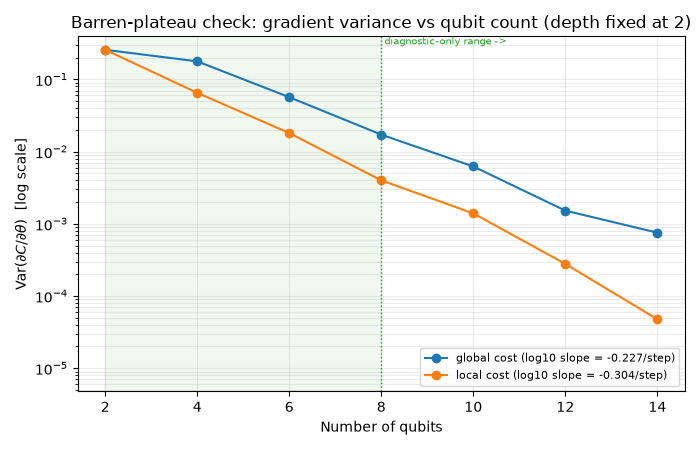

In [4]:
summary_df = pd.read_csv(SUMMARY_CSV) if SUMMARY_CSV.exists() else pd.DataFrame()

if not summary_df.empty:
    sweep_a_df = summary_df[summary_df['sweep'] == 'qubits'].sort_values(['n_qubits', 'cost_type'])
    display(sweep_a_df)
    fig_path = project_root / 'figures' / 'gradient_variance_vs_qubits.png'
    if fig_path.exists():
        display(Image(filename=str(fig_path)))
else:
    print('No results yet -- run:\n  python -m src.experiments.run_barren_plateau_check --sweep qubits --extended')

In [5]:
def trend_table(df, x_column):
    '''Per-step decay rate, fitted only over non-degenerate points.'''
    out = []
    for cost_type in COST_TYPES:
        group = df[df['cost_type'] == cost_type].sort_values(x_column)
        fittable = group[group['gradient_variance'] > GRADIENT_ZERO_TOL]
        degenerate = group[group['gradient_variance'] <= GRADIENT_ZERO_TOL]
        slope = (np.polyfit(fittable[x_column], np.log10(fittable['gradient_variance']), 1)[0]
                 if len(fittable) >= 2 else np.nan)
        out.append({
            'cost_type': cost_type,
            'log10_slope_per_step': slope,
            'fold_change_per_step': 10 ** slope if np.isfinite(slope) else np.nan,
            'decades_spanned': (np.log10(fittable['gradient_variance'].max()
                                         / fittable['gradient_variance'].min())
                                if len(fittable) >= 2 else np.nan),
            'structurally_zero_points': len(degenerate),
        })
    return pd.DataFrame(out)

sweep_a_trend = trend_table(sweep_a_df, 'n_qubits')
display(sweep_a_trend)

# Restricted to the range this project actually trains models over.
sweep_a_trained_only = sweep_a_df[sweep_a_df['n_qubits'] <= max(QUBIT_POINTS)]
print('Restricted to the trainable range (2-8 qubits) only:')
display(trend_table(sweep_a_trained_only, 'n_qubits'))

,cost_type,log10_slope_per_step,fold_change_per_step,decades_spanned,structurally_zero_points
0,global,-0.226676,0.593368,2.532841,0
1,local,-0.304453,0.496075,3.732687,0


Restricted to the trainable range (2-8 qubits) only:


,cost_type,log10_slope_per_step,fold_change_per_step,decades_spanned,structurally_zero_points
0,global,-0.201100,0.629361,1.175244,0
1,local,-0.299139,0.502182,1.808457,0


## 3. Sweep B -- gradient variance vs circuit depth

`n_qubits` fixed at 4. Note the hollow down-triangles: at depths 1 and 3 the *local* cost gradient is
**exactly zero to machine precision** ($\sim 10^{-33}$), not merely small. Those points cannot be drawn on
a log axis or folded into a decay fit -- a $10^{-33}$ would stretch the axis over thirty meaningless
decades -- so they are marked separately rather than silently dropped. Section 5 explains why they are zero.

,sweep,n_qubits,n_qlayers,cost_type,param_index,gradient_variance,gradient_mean,n_samples,seed
0,depth,4,1,global,0,0.564071,0.054906,200,42
1,depth,4,1,local,0,1.631818e-33,2.654262e-19,200,42
2,depth,4,2,global,0,0.178040,-0.024294,200,42
3,depth,4,2,local,0,0.065265,-0.015068,200,42
4,depth,4,3,global,0,0.062638,-0.018273,200,42
5,depth,4,3,local,0,2.020930e-33,-3.377561e-18,200,42
6,depth,4,4,global,0,0.136190,-0.042284,200,42
7,depth,4,4,local,0,0.067826,-0.019497,200,42


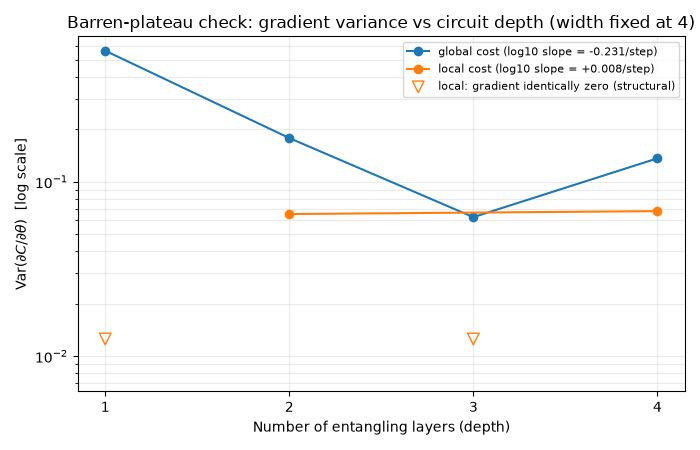

In [6]:
if not summary_df.empty:
    sweep_b_df = summary_df[summary_df['sweep'] == 'depth'].sort_values(['n_qlayers', 'cost_type'])
    display(sweep_b_df)
    fig_path = project_root / 'figures' / 'gradient_variance_vs_depth.png'
    if fig_path.exists():
        display(Image(filename=str(fig_path)))
else:
    print('No results yet -- run:\n  python -m src.experiments.run_barren_plateau_check --sweep depth')

In [7]:
display(trend_table(sweep_b_df, 'n_qlayers'))

print('Global-cost variance by depth (no monotonic trend -- it falls then rises again):')
global_by_depth = sweep_b_df[sweep_b_df['cost_type'] == 'global'][['n_qlayers', 'gradient_variance']]
display(global_by_depth.set_index('n_qlayers'))

,cost_type,log10_slope_per_step,fold_change_per_step,decades_spanned,structurally_zero_points
0,global,-0.230524,0.588133,0.954499,0
1,local,0.008358,1.019433,0.016717,2


Global-cost variance by depth (no monotonic trend -- it falls then rises again):


,gradient_variance
n_qlayers,
1,0.564071
2,0.178040
3,0.062638
4,0.136190


## 4. Local vs global cost

The direct evidence on whether switching `HybridCNN` to a local readout would help. A ratio **> 1**
would mean the local cost has the healthier landscape and the swap is worth making; **< 1** means it
is not.

In [8]:
def ratio_table(df, x_column):
    pivot = df.pivot_table(index=x_column, columns='cost_type', values='gradient_variance')
    pivot['local_over_global'] = pivot['local'] / pivot['global']
    pivot['local_is_structurally_zero'] = pivot['local'] <= GRADIENT_ZERO_TOL
    return pivot

print('Sweep A -- by qubit count:')
display(ratio_table(sweep_a_df, 'n_qubits'))

print('Sweep B -- by depth:')
display(ratio_table(sweep_b_df, 'n_qlayers'))

Sweep A -- by qubit count:


cost_type,global,local,local_over_global,local_is_structurally_zero
n_qubits,,,,
2,0.257320,0.257320,1.000000,False
4,0.178040,0.065265,0.366575,False
6,0.056787,0.018083,0.318444,False
8,0.017188,0.004000,0.232695,False
10,0.006229,0.001396,0.224095,False
12,0.001523,2.787715e-04,0.183010,False
14,7.544533e-04,4.761963e-05,0.063118,False


Sweep B -- by depth:


cost_type,global,local,local_over_global,local_is_structurally_zero
n_qlayers,,,,
1,0.564071,1.631818e-33,2.892932e-33,True
2,0.178040,0.065265,0.366575,False
3,0.062638,2.020930e-33,3.226385e-32,True
4,0.136190,0.067826,0.498024,False


### Reading the ratio honestly

The local cost is **never** better here, but part of that gap is arithmetic rather than landscape
geometry: the global cost is a **sum of $n$ single-qubit terms**, and summing $n$ correlated terms
inflates variance relative to any single term. To separate "the global landscape is genuinely healthier"
from "the global cost simply has more terms in it", the cell below rescales the global cost to a *mean*
over wires, $C = \frac{1}{n}\sum_i \langle Z_i \rangle$, which puts both costs on a per-observable footing.

In [9]:
# Var(sum/n) = Var(sum)/n^2 -- rescaling the global cost to a per-wire mean.
normalised = sweep_a_df.pivot_table(index='n_qubits', columns='cost_type', values='gradient_variance')
normalised['global_as_mean'] = normalised['global'] / (normalised.index.values ** 2)
normalised['local_over_global_mean'] = normalised['local'] / normalised['global_as_mean']
display(normalised[['global', 'global_as_mean', 'local', 'local_over_global_mean']])

print('Once the global cost is put on a per-wire footing, the local cost has the LARGER variance')
print('at every qubit count -- so the raw ratio in section 4 mostly reflects the number of summed')
print('terms, not a genuinely healthier global landscape.')

cost_type,global,global_as_mean,local,local_over_global_mean
n_qubits,,,,
2,0.257320,0.064330,0.257320,4.000000
4,0.178040,0.011127,0.065265,5.865195
6,0.056787,0.001577,0.018083,11.463971
8,0.017188,2.685651e-04,0.004000,14.892484
10,0.006229,6.228824e-05,0.001396,22.409456
12,0.001523,1.057816e-05,2.787715e-04,26.353508
14,7.544533e-04,3.849252e-06,4.761963e-05,12.371138


Once the global cost is put on a per-wire footing, the local cost has the LARGER variance
at every qubit count -- so the raw ratio in section 4 mostly reflects the number of summed
terms, not a genuinely healthier global landscape.


## 5. Why the local-cost gradient is *exactly* zero at odd depth

At `n_qlayers` in {1, 3} the sampled variance of $\partial \langle Z_0 \rangle / \partial \theta$ is
$\sim 10^{-33}$ -- machine zero, not a small number. This is **not** a barren plateau. It is an exact
structural decoupling produced by `BasicEntanglerLayers`' CNOT **ring**.

Propagating $Z_0$ backwards through one entangling layer on 4 qubits (CNOT conjugation sends
$Z_{\text{target}} \to Z_{\text{control}} Z_{\text{target}}$):

$$Z_0 \xrightarrow{\text{CNOT}(3,0)} Z_3 Z_0 \xrightarrow{\text{CNOT}(2,3)} Z_2 Z_3 Z_0
\xrightarrow{\text{CNOT}(1,2)} Z_1 Z_2 Z_3 Z_0 \xrightarrow{\text{CNOT}(0,1)} Z_0 Z_1 Z_2 Z_3 Z_0 = Z_1 Z_2 Z_3$$

The two $Z_0$ factors cancel ($Z^2 = I$), so after one layer $\langle Z_0 \rangle$ equals an observable with
**no support at all** on wire 0 -- the wire that $\theta = $ `weights[0][0]` rotates. The derivative is therefore
identically zero for *any* input state, not just $|0\ldots0\rangle$.

The cells below verify this three ways: numerically, by input-independence, and by showing the zero moves
to a different parameter index at a different depth (so it is a specific decoupling, not a dead cost function).

In [10]:
print('Direct check: <Z> vs theta at depth 1, n_qubits=4, zeros input.')
print('Wire 0 is pinned at exactly +1 for every theta, while the other wires respond:\n')

qnode_d1 = make_quantum_layer(4, 1).qnode
for theta in [0.0, 0.7, 1.5, 3.0]:
    w = torch.zeros(1, 4, dtype=torch.float64)
    w[0, 0] = theta
    expvals = torch.stack(list(qnode_d1(torch.zeros(4, dtype=torch.float64), w)))
    print(f'  theta={theta:.2f} -> <Z> = ' + '  '.join(f'{v:+.6f}' for v in expvals.tolist()))

Direct check: <Z> vs theta at depth 1, n_qubits=4, zeros input.
Wire 0 is pinned at exactly +1 for every theta, while the other wires respond:

  theta=0.00 -> <Z> = +1.000000  +1.000000  +1.000000  +1.000000
  theta=0.70 -> <Z> = +1.000000  +0.764842  +0.764842  +0.764842
  theta=1.50 -> <Z> = +1.000000  +0.070737  +0.070737  +0.070737
  theta=3.00 -> <Z> = +1.000000  -0.989992  -0.989992  -0.989992


In [11]:
print('The zero is a property of the ansatz, not of which parameter we happened to pick.')
print('It simply moves to a different parameter index as depth changes:\n')

rows = []
for n_qlayers in [1, 2]:
    for param_index in range(4):
        g = sample_gradients(4, n_qlayers, 100, 42, param_index=param_index)
        rows.append({
            'n_qlayers': n_qlayers,
            'param_index': param_index,
            'local_variance': np.var(g['local']),
            'global_variance': np.var(g['global']),
            'local_is_zero': np.var(g['local']) <= GRADIENT_ZERO_TOL,
        })
display(pd.DataFrame(rows))

The zero is a property of the ansatz, not of which parameter we happened to pick.
It simply moves to a different parameter index as depth changes:



,n_qlayers,param_index,local_variance,global_variance,local_is_zero
0,1,0,1.517735e-33,0.574204,True
1,1,1,0.143031,0.736962,False
2,1,2,0.105780,0.192233,False
3,1,3,0.134729,0.190787,False
4,2,0,0.072134,0.207038,False
5,2,1,0.061243,0.147786,False
6,2,2,1.145995e-33,0.127548,True
7,2,3,0.057805,0.187631,False


## 6. Robustness: is any of this an artifact of the all-zero reference input?

McClean's convention starts from $|0\ldots0\rangle$, but `HybridCNN` never feeds the circuit zeros -- it
feeds $\tanh(\cdot) \times \pi$ of a learned linear layer, i.e. arbitrary angles in $[-\pi, \pi]$. If the
decline in Sweep A only existed for the zero state it would say nothing about the trained model, so both
sweeps are repeated below with a fixed *non-zero* representative embedding.

In [12]:
print('Qubit sweep, reference_input="random" (a fixed non-zero embedded sample):')
rows = []
for n_qubits in QUBIT_POINTS + EXTENDED_QUBIT_POINTS:
    g = sample_gradients(n_qubits, 2, 200, 42, reference_input='random')
    rows.append({'n_qubits': n_qubits,
                 'global_variance': np.var(g['global']),
                 'local_variance': np.var(g['local'])})
random_input_qubits = pd.DataFrame(rows)
display(random_input_qubits)

slope_zeros = np.polyfit(sweep_a_df[sweep_a_df.cost_type == 'global']['n_qubits'],
                         np.log10(sweep_a_df[sweep_a_df.cost_type == 'global']['gradient_variance']), 1)[0]
slope_random = np.polyfit(random_input_qubits['n_qubits'],
                          np.log10(random_input_qubits['global_variance']), 1)[0]
print(f'global-cost log10 slope, zeros input : {slope_zeros:+.4f} per qubit')
print(f'global-cost log10 slope, random input: {slope_random:+.4f} per qubit')
print('-> the decline is not an artifact of starting from |0...0>.')

Qubit sweep, reference_input="random" (a fixed non-zero embedded sample):


,n_qubits,global_variance,local_variance
0,2,0.245306,0.245306
1,4,0.208843,0.074147
2,6,0.062978,0.013547
3,8,0.014927,0.002934
4,10,0.005568,0.001082
5,12,0.001800,2.882625e-04
6,14,5.625589e-04,4.412624e-05


global-cost log10 slope, zeros input : -0.2267 per qubit
global-cost log10 slope, random input: -0.2340 per qubit
-> the decline is not an artifact of starting from |0...0>.


In [13]:
print('Depth sweep, reference_input="random":')
rows = []
for n_qlayers in DEPTH_POINTS:
    g = sample_gradients(4, n_qlayers, 200, 42, reference_input='random')
    rows.append({'n_qlayers': n_qlayers,
                 'global_variance': np.var(g['global']),
                 'local_variance': np.var(g['local']),
                 'local_is_zero': np.var(g['local']) <= GRADIENT_ZERO_TOL})
display(pd.DataFrame(rows))
print('The odd-depth local-cost zeros survive a non-zero input, confirming the algebraic')
print('argument in section 5: the decoupling is input-independent.')

Depth sweep, reference_input="random":


,n_qlayers,global_variance,local_variance,local_is_zero
0,1,0.584485,2.686248e-33,True
1,2,0.208843,0.074147,False
2,3,0.059580,3.319983e-33,True
3,4,0.097361,0.051075,False


The odd-depth local-cost zeros survive a non-zero input, confirming the algebraic
argument in section 5: the decoupling is input-independent.


## 7. Cross-reference against Experiment 3's accuracy

The point of the whole exercise: if gradient variance and accuracy move together, the barren plateau is a
live explanation for Experiment 3's flat sweeps. If they do not, it is ruled out.

In [14]:
ablation_csv = project_root / 'results' / 'ablation' / 'metrics_summary.csv'
if ablation_csv.exists():
    ablation_df = pd.read_csv(ablation_csv)

    for sweep, x_column in [('qubits', 'n_qubits'), ('depth', 'n_qlayers')]:
        acc = ablation_df[ablation_df['sweep'] == sweep][[x_column, 'accuracy']]
        var = summary_df[(summary_df['sweep'] == sweep) & (summary_df['cost_type'] == 'global')]
        merged = acc.merge(var[[x_column, 'gradient_variance']], on=x_column, how='inner')
        merged = merged.sort_values(x_column)
        print(f'--- Sweep {sweep}: Experiment 3 accuracy vs Phase 7 global-cost gradient variance ---')
        display(merged.set_index(x_column))
        if len(merged) >= 3:
            corr = merged['accuracy'].corr(merged['gradient_variance'])
            print(f'Pearson correlation (accuracy, gradient_variance): {corr:+.3f}\n')
else:
    print(f'No ablation summary at {ablation_csv} -- run run_ablation.py first.')

--- Sweep qubits: Experiment 3 accuracy vs Phase 7 global-cost gradient variance ---


,accuracy,gradient_variance
n_qubits,,
2,0.993333,0.257320
4,0.976667,0.178040
6,0.996667,0.056787
8,0.980000,0.017188


Pearson correlation (accuracy, gradient_variance): +0.119

--- Sweep depth: Experiment 3 accuracy vs Phase 7 global-cost gradient variance ---


,accuracy,gradient_variance
n_qlayers,,
1,0.993333,0.564071
2,0.976667,0.178040
3,0.986667,0.062638
4,0.990000,0.136190


Pearson correlation (accuracy, gradient_variance): +0.502



## Interpretation notes

### The headline result is *not* the expected flat line

The prior going in was that gradient variance would be flat across 2-8 qubits and 1-4 layers, given how
small those numbers are, which would have cleanly ruled out the barren plateau and left the ceiling-effect
explanation standing. **That is not what the measurement shows.**

**Sweep A (qubit count) shows a clean exponential decline**, and it is already visible *inside* the range this
project trains over. Global-cost variance falls from $2.57 \times 10^{-1}$ at 2 qubits to
$1.72 \times 10^{-2}$ at 8 -- a **15-fold drop across 1.2 decades**, tracking a straight line on the log axis
with a fitted slope of $-0.227$ per qubit (roughly a factor of 0.59 per qubit added). Extending the diagnostic to
14 qubits continues the same straight line to $7.5 \times 10^{-4}$, 2.5 decades below the 2-qubit value, with no
sign of levelling off. On the log plot this is the textbook barren-plateau signature.

**Sweep B (circuit depth) shows no such trend.** Global-cost variance goes 0.564 -> 0.178 -> 0.063 -> 0.136 across
depths 1-4: it falls, then *rises again* at depth 4, spanning under one decade with no monotonic direction. Depth,
over the 1-4 range this project uses, is not driving the landscape flat.

### What this does and does not license saying

The decay is real and measurable, but three qualifications matter before it is written up as "Experiment 3 was
limited by a barren plateau":

1. **The magnitudes are still workable.** At the project's actual operating point (4 qubits, 2 layers) the variance
   is $1.8 \times 10^{-1}$; even at 8 qubits it is $1.7 \times 10^{-2}$. These are not the $10^{-6}$-and-below
   gradients at which optimisation genuinely stalls. The *trend* is exponential; the *values* inside the tested
   range are not yet small enough to explain a training failure.
2. **The direction of the decay does not match Experiment 4's instability.** The unstable configuration in
   Experiment 4 was `depth_1` -- and depth 1 has the **largest** global-cost gradient variance of any point measured
   (0.564). Whatever caused the class-collapse in 2/5 seeds at depth 1, it was not vanishing gradients. This
   reinforces the dissertation's existing position that the two phenomena are distinct.
3. **The accuracy sweep does not track the variance sweep.** Section 7 shows accuracy staying near-ceiling
   (97.7%-99.7%) across exactly the qubit range over which variance falls 15-fold. If the plateau were binding,
   accuracy would degrade with it. It does not -- which is itself the cleanest evidence that the **ceiling effect
   remains the operative explanation** for Experiments 1-3, even though the barren-plateau mechanism is
   measurably present in the background.

So the honest framing for Section 6.1 is: *the barren-plateau mechanism is detectable in this ansatz and scales
as theory predicts with qubit count, but it is not yet the binding constraint at the 4-8 qubit scale this project
operates at.* That is a stronger and more defensible claim than either "no plateau here" or "the plateau explains
our results", and it is now backed by a direct measurement instead of an inference from accuracy.

### Local cost is not the mitigation here

The standard mitigation (Cerezo et al. 2021) is to replace a global cost with a local one. On this ansatz that
swap is not worth making -- but the reason is subtler than the raw numbers first suggest, because the two obvious
comparisons point in *opposite* directions:

- Against the cost the model actually uses, $C = \sum_i \langle Z_i \rangle$, the local cost has **lower**
  variance everywhere (0.37x at 4 qubits, falling to 0.06x at 14).
- But put on a per-wire footing, $C = \frac{1}{n}\sum_i \langle Z_i \rangle$, the ordering **reverses**: the
  local cost has 4x-26x the variance of the global one (section 4).

Neither comparison settles anything on its own, because **rescaling a cost by a constant is not a change of
landscape** -- multiplying $C$ by $1/n$ divides the gradient by $n$ and the variance by $n^2$, which an optimiser
absorbs into its learning rate. The scale-free quantity is the **decay rate**, which is invariant to that
rescaling, and there the local cost is unambiguously worse: its variance falls at $-0.304$ per qubit against the
global cost's $-0.227$. Switching readout would make the qubit-count scaling *steeper*, not shallower -- the
opposite of what the mitigation is supposed to buy.

The decisive objection is structural rather than statistical:

- **At odd depths the local gradient is exactly zero.** At `n_qlayers` in {1, 3}, $\partial \langle Z_0 \rangle /
  \partial\,\text{weights}[0][0]$ vanishes identically ($\sim 10^{-33}$), because the CNOT ring conjugates $Z_0$ into
  an operator with no support on wire 0 (section 5). A model trained on a single-wire readout would have a genuinely
  untrainable parameter at those depths. This is a property of `BasicEntanglerLayers`' ring topology, verified to be
  input-independent and to move to a different parameter index at a different depth -- so it is a real structural
  degeneracy, not a numerical accident. The current all-wires readout is what saves the project from it: summing over
  every wire guarantees no single parameter can be orphaned by the ring.

The caveat to state alongside this: the "global" cost measured here is a **sum of single-qubit observables**, because
that is what `HybridCNN`'s `output_head` reads, *not* an $n$-body product observable like $Z^{\otimes n}$. Cerezo et
al.'s sharp global-vs-local separation is proved for the latter. So this result is evidence about **this model's
readout**, and is not a counterexample to the global-cost literature.

### Suggested follow-ups

- Push the qubit sweep to 16-20 to find where variance actually reaches the $10^{-6}$ regime -- that locates the
  qubit count at which this ansatz would stop being trainable, which is a useful scaling statement for the writeup.
- Repeat the diagnostic across several `sampling_seed` values to put an error bar on the variance estimates
  themselves (200 samples gives a fairly noisy variance estimate).
- If a local readout is ever reconsidered, avoid wire 0 / `weights[0][0]` specifically, or replace the CNOT ring
  with a non-periodic entangling topology that does not produce the cancellation in section 5.